<a href="https://colab.research.google.com/github/ArtemijAE/image_procesingGG/blob/main/Ilin_A_YOLO_MSFD_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics -q
!pip install gdown -q

import torch
print(f"GPU: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.2 MB/s eta 0:00:00
GPU: True


Скачка архива с преобразованными данными из MSFD под формат YOLO.

Преобразованные данные - https://drive.google.com/file/d/1A3cf_UZUKcqIibD9bD6QTyHpchMkDkTz/view


In [ ]:
file_id = "1A3cf_UZUKcqIibD9bD6QTyHpchMkDkTz"
output_name = "MSFD_YOLO.zip"
!gdown "https://drive.google.com/uc?id={file_id}" -O "{output_name}"
import os
print(f"Скачано:{output_name}")

Downloading...
From (original): https://drive.google.com/uc?id=1A3cf_UZUKcqIibD9bD6QTyHpchMkDkTz
From (redirected): https://drive.google.com/uc?id=1A3cf_UZUKcqIibD9bD6QTyHpchMkDkTz&confirm=t&uuid=d7380fe5-dd19-4732-a820-053dd1b54cac
To: /content/MSFD_YOLO.zip
100% 299M/299M [00:06<00:00, 44.8MB/s]
Скачано:MSFD_YOLO.zip


Обработка загруженных данных.


In [ ]:
import zipfile
import os
import shutil
current_path = "/content/MSFD_YOLO"
nested_path = "/content/MSFD_YOLO/MSFD_YOLO"
if os.path.exists(nested_path):
    for item in os.listdir(nested_path):
        src = os.path.join(nested_path, item)
        dst = os.path.join(current_path, item)
        if os.path.exists(dst):
            if os.path.isdir(src):
                for subitem in os.listdir(src):
                    sub_src = os.path.join(src, subitem)
                    sub_dst = os.path.join(dst, subitem)
                    if os.path.exists(sub_dst):
                        os.remove(sub_dst) if os.path.isfile(sub_dst) else shutil.rmtree(sub_dst)
                    shutil.move(sub_src, sub_dst)
            else:
                os.remove(dst)
                shutil.move(src, dst)
        else:
            shutil.move(src, dst)
    if os.path.exists(nested_path):
        shutil.rmtree(nested_path)
import yaml
data_yaml = "/content/MSFD_YOLO/data.yaml"
with open(data_yaml, 'r') as f:
    config = yaml.safe_load(f)
config['path'] = "/content/MSFD_YOLO"
with open(data_yaml, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)
train_path = os.path.join(config['path'], config['train'])
val_path = os.path.join(config['path'], config['val'])
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
all_items = os.listdir("/content/MSFD_YOLO")
if 'images' not in all_items:
    jpg_files = []
    for root, dirs, files in os.walk("/content/MSFD_YOLO"):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                jpg_files.append(os.path.join(root, file))
    if jpg_files:
        import random
        random.shuffle(jpg_files)
        split_idx = int(len(jpg_files) * 0.8)
        train_files = jpg_files[:split_idx]
        val_files = jpg_files[split_idx:]
        moved = 0
        for src in train_files:
            dst = os.path.join(train_path, os.path.basename(src))
            if not os.path.exists(dst):
                shutil.move(src, dst)
                moved += 1
        moved = 0
        for src in val_files:
            dst = os.path.join(val_path, os.path.basename(src))
            if not os.path.exists(dst):
                shutil.move(src, dst)
                moved += 1
train_images = [f for f in os.listdir(train_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
val_images = [f for f in os.listdir(val_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"Train: {len(train_images)}")
print(f"Val: {len(val_images)}")

Train: 7505
Val: 1877


Обучение модели.

In [ ]:
from ultralytics import YOLO
import time

model = YOLO('yolo11n-seg.pt')
data_yaml = "/content/MSFD_YOLO/data.yaml"

training_args = {
    'data': data_yaml,
    'epochs': 100,
    'imgsz': 256,
    'batch': 16,
    'workers': 4,
    'device': 0,
    'name': 'face_mask_segmentation',
    'save': True,
    'save_period': 25,
    'patience': 50,
    'verbose': True,
    'cos_lr': True,
    'lr0': 0.01,
    'lrf': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'warmup_momentum': 0.8,
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,
    'mask_ratio': 4,
}

print(f"Обучение на {len(os.listdir(os.path.join(data_path, 'images/train')))}")
print(f"epochs: {training_args['epochs']}, size: {training_args['imgsz']}")

start_time = time.time()
results = model.train(**training_args)
end_time = time.time()

print(f"Обучение завершено за {(end_time - start_time)/3600:.1f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Обучение на 7505
epochs: 100, size: 256
Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/MSFD_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

KeyboardInterrupt: 

Валидация, сохранение метрик

In [ ]:
import glob
import os

runs_dir = "/content/runs/segment/face_mask_segmentation"
best_model_path = os.path.join(runs_dir, "weights", "best.pt")

if os.path.exists(best_model_path):
    from ultralytics import YOLO
    best_model = YOLO(best_model_path)
    metrics = best_model.val(data="/content/MSFD_YOLO/data.yaml", imgsz=256, batch=16, device=0)

    print("Метрики after 6 epochs")
    print(f"Точность bounding boxes:")
    print(f"mAP50: {metrics.box.map50:.4f}")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"Precision: {metrics.box.p[0]:.4f}" if hasattr(metrics.box.p, '__len__') else f"Precision: {metrics.box.p:.4f}")
    print(f"Recall: {metrics.box.r[0]:.4f}" if hasattr(metrics.box.r, '__len__') else f"Recall: {metrics.box.r:.4f}")
    print(f"Точность масок:")
    print(f"mAP50: {metrics.seg.map50:.4f}")
    print(f"mAP50-95: {metrics.seg.map:.4f}")
    print(f"Precision: {metrics.seg.p[0]:.4f}" if hasattr(metrics.seg.p, '__len__') else f"Precision: {metrics.seg.p:.4f}")
    print(f"Recall: {metrics.seg.r[0]:.4f}" if hasattr(metrics.seg.r, '__len__') else f"Recall: {metrics.seg.r:.4f}")
    with open(os.path.join(runs_dir, "final_metrics.txt"), "w") as f:
        f.write("Сегментация:\n")
        f.write(f"mAP50: {metrics.seg.map50:.4f}\n")
        f.write(f"mAP50-95: {metrics.seg.map:.4f}\n")
        f.write(f"Precision: {metrics.seg.p[0] if hasattr(metrics.seg.p, '__len__') else metrics.seg.p:.4f}\n")
        f.write(f"Recall: {metrics.seg.r[0] if hasattr(metrics.seg.r, '__len__') else metrics.seg.r:.4f}\n\n")
        f.write("Bounding boxes:\n")
        f.write(f"mAP50: {metrics.box.map50:.4f}\n")
        f.write(f"mAP50-95: {metrics.box.map:.4f}\n")
        f.write(f"Precision: {metrics.box.p[0] if hasattr(metrics.box.p, '__len__') else metrics.box.p:.4f}\n")
        f.write(f"Recall: {metrics.box.r[0] if hasattr(metrics.box.r, '__len__') else metrics.box.r:.4f}\n")

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1219.4±1127.7 MB/s, size: 29.4 KB)
val: Scanning /content/MSFD_YOLO/labels/val.cache... 1877 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1877/1877 3.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 118/118 6.6it/s 17.8s
                   all       1877       2008      0.992       0.92      0.935      0.801      0.987      0.916      0.925      0.814
Speed: 0.2ms preprocess, 1.6ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/segment/val3
Метрики after 6 epochs
Точность bounding boxes:
mAP50: 0.9349
mAP50-95: 0.8011
Precision: 0.9923
Recall: 0.9203
Точность масок:
mAP50: 0.9254
mAP50-95: 0.8144
Precision: 0.9875
R

Тест



Тестируем: 007277_3.jpg

image 1/1 /content/MSFD_YOLO/images/val/007277_3.jpg: 256x256 1 face_mask, 16.0ms
Speed: 0.6ms preprocess, 16.0ms inference, 5.0ms postprocess per image at shape (1, 3, 256, 256)
Найдено масок: 1


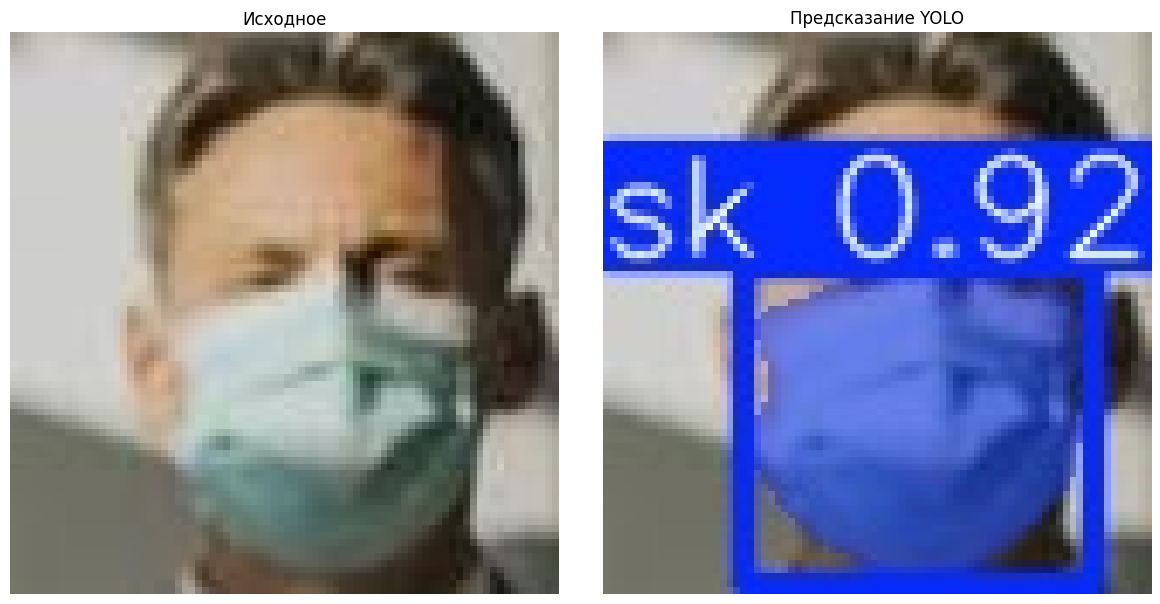


Тестируем: 007670_10.jpg

image 1/1 /content/MSFD_YOLO/images/val/007670_10.jpg: 256x256 1 face_mask, 17.2ms
Speed: 1.0ms preprocess, 17.2ms inference, 4.0ms postprocess per image at shape (1, 3, 256, 256)
Найдено масок: 1


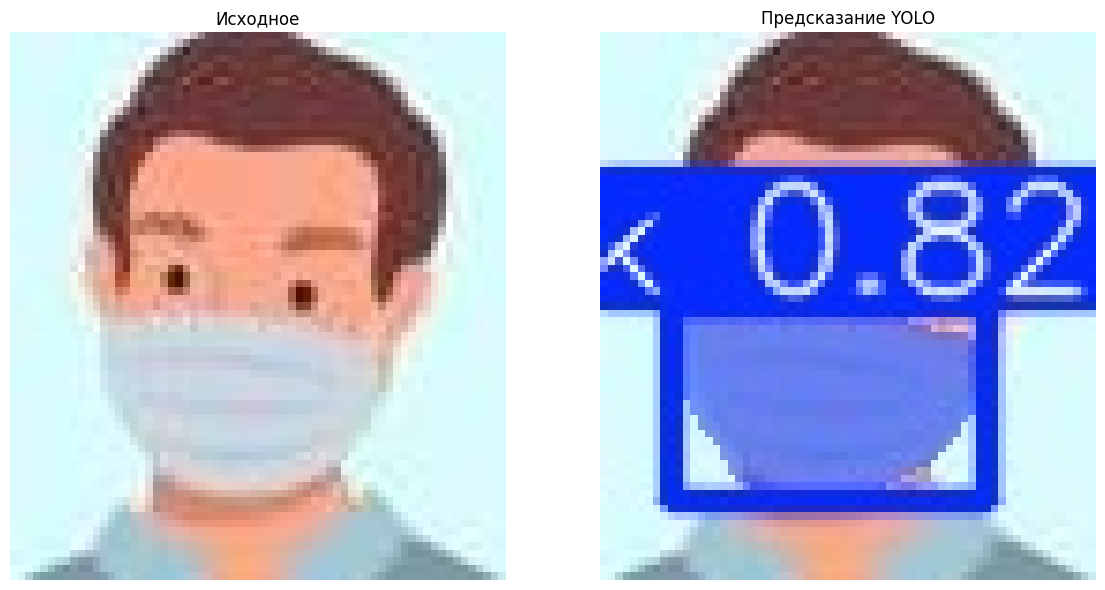


Тестируем: 001111_1.jpg

image 1/1 /content/MSFD_YOLO/images/val/001111_1.jpg: 256x224 1 face_mask, 67.1ms
Speed: 1.2ms preprocess, 67.1ms inference, 3.3ms postprocess per image at shape (1, 3, 256, 224)
Найдено масок: 1


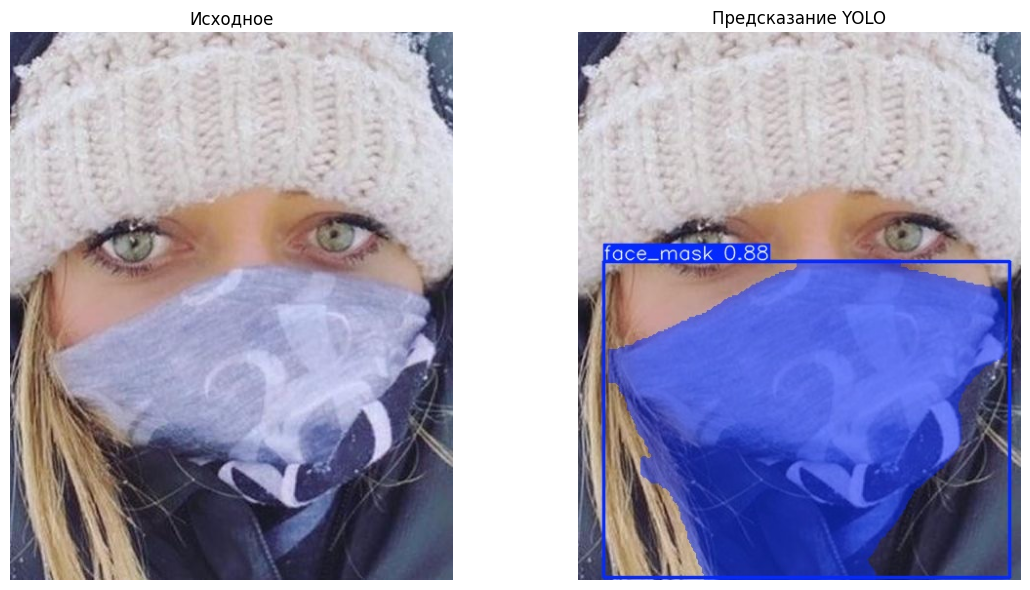

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

data_path = "/content/MSFD_YOLO"
val_dir = os.path.join(data_path, "images/val")

if os.path.exists(best_model_path):
    from ultralytics import YOLO
    best_model = YOLO(best_model_path)

    val_images = os.listdir(val_dir)
    test_images = random.sample(val_images, min(3, len(val_images)))

    for img_name in test_images:
        img_path = os.path.join(val_dir, img_name)

        print(f"\nТестируем: {img_name}")
        results = best_model(img_path, conf=0.25, device=0)

        for result in results:
            if result.masks is not None:
                print(f"Найдено масок: {len(result.masks)}")
                result.save(filename=f"pred_{img_name}")

                fig, axes = plt.subplots(1, 2, figsize=(12, 6))
                img = Image.open(img_path)
                axes[0].imshow(img)
                axes[0].set_title('Исходное')
                axes[0].axis('off')

                pred_img = Image.open(f"pred_{img_name}")
                axes[1].imshow(pred_img)
                axes[1].set_title('Предсказание YOLO')
                axes[1].axis('off')

                plt.tight_layout()
                plt.show()
            else:
                print(f"Маски не обнаружены")
else:
    print("Модель не найдена")

Сохранение


In [ ]:
from google.colab import drive
from datetime import datetime
import shutil
drive.mount('/content/drive')
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"/content/drive/MyDrive/YOLO_Results/{timestamp}"
os.makedirs(save_dir, exist_ok=True)
print(f"Сохраняем в: {save_dir}")
if os.path.exists(best_model_path):
    shutil.copy2(best_model_path, os.path.join(save_dir, "best_7epochs.pt"))
    print("Модель сохранена: best_7epochs.pt")

    weights_dir = os.path.join(runs_dir, "weights")
    if os.path.exists(weights_dir):
        shutil.copytree(weights_dir, os.path.join(save_dir, "weights"), dirs_exist_ok=True)
    for plot in glob.glob(os.path.join(runs_dir, "*.png")):
        shutil.copy2(plot, save_dir)
    print(f"\nСохранено")
    print(f"Путь: {timestamp}")
else:
    print("Модель не найдена")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Сохраняем в: /content/drive/MyDrive/YOLO_Results/20251217_103049
Модель сохранена: best_7epochs.pt

Сохранено
Путь: 20251217_103049
